# Config 

Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 460
Val samples:   116


c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [01/30] | Train Loss: 0.000382 | Val Loss: 0.000427 | Val MAE: 0.022454 | Val RMSE: 0.029211 | Val R2: -1.060055
Epoch [02/30] | Train Loss: 0.000330 | Val Loss: 0.000304 | Val MAE: 0.019891 | Val RMSE: 0.024656 | Val R2: -0.467626
Epoch [03/30] | Train Loss: 0.000307 | Val Loss: 0.000304 | Val MAE: 0.019422 | Val RMSE: 0.024666 | Val R2: -0.468844
Epoch [04/30] | Train Loss: 0.000273 | Val Loss: 0.000259 | Val MAE: 0.018140 | Val RMSE: 0.022760 | Val R2: -0.250602
Epoch [05/30] | Train Loss: 0.000251 | Val Loss: 0.000232 | Val MAE: 0.016960 | Val RMSE: 0.021546 | Val R2: -0.120759
Epoch [06/30] | Train Loss: 0.000243 | Val Loss: 0.000222 | Val MAE: 0.016694 | Val RMSE: 0.021092 | Val R2: -0.074004
Epoch [07/30] | Train Loss: 0.000246 | Val Loss: 0.000220 | Val MAE: 0.016716 | Val RMSE: 0.020958 | Val R2: -0.060462
Epoch [08/30] | Train Loss: 0.000210 | Val Loss: 0.000207 | Val MAE: 0.015867 | Val RMSE: 0.020360 | Val R2: -0.000750
Epoch [09/30] | Train Loss: 0.000232 | Val Loss:

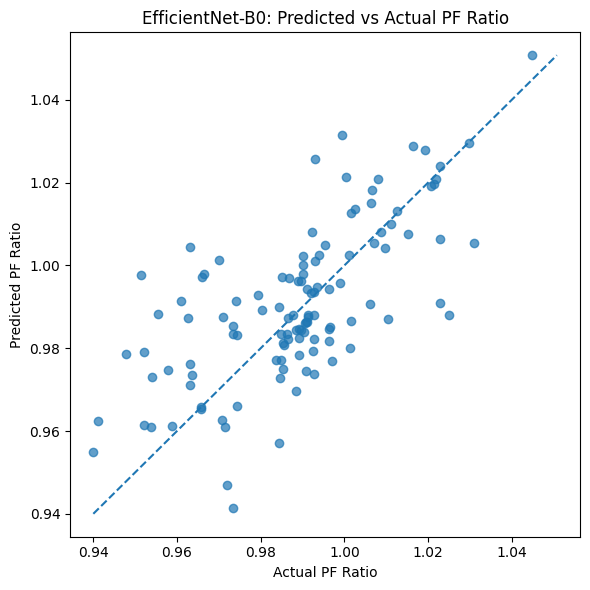


Model saved to: efficientnet_b0_el_pf_ratio_from_AnonDB.pth


In [4]:
import os
import math
import copy
import random
from xml.parsers.expat import model
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"          # original CSV file
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
RANDOM_SEED = 42
NUM_WORKERS = 0   # use 0 first, especially on Windows/Jupyter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths like './EL/3903_35_1_01272020_20.tiff'
    into absolute paths based on the CSV/script directory.

    If add_wrp=True, convert:
    3903_35_1_01272020_20.tiff
    -> 3903_35_1_01272020_20_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    # Normalize slashes
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    # Add _wrp before file extension if needed
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    # If already absolute, keep it
    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    # Remove leading ./ if present
    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load original CSV, compute PF ratio, resolve paths, and
    keep only valid rows with existing low/high EL files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    # Convert power columns to numeric safely
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    # Remove invalid denominator
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    # Remove invalid numerator
    df = df[df["Pmp_(W)"].notna()]

    # Compute PF ratio
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Resolve actual paths
    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    # Remove missing path strings
    df = df[df["low_path"].notna()]
    df = df[df["high_path"].notna()]

    # Keep only rows whose image files actually exist
    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    # Keep only needed columns
    keep_cols = ["low_path", "high_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================

class SingleELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def apply_augmentation(self, img):
        # Horizontal flip
        if random.random() < 0.5:
            img = cv2.flip(img, 1)

        # Vertical flip
        if random.random() < 0.5:
            img = cv2.flip(img, 0)

        return img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ✅ Only one image now
        img = self.read_grayscale_tiff(row["high_path"])

        img = self.resize_image(img)

        if self.augment:
            img = self.apply_augmentation(img)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        img = np.expand_dims(img, axis=0)

        x = torch.tensor(img, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y

# Define BoundedOutput FIRST (before the build function)
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val

# =========================================================
# MODEL ini yang bikin copilot
# =========================================================
def build_efficientnet_b0_1ch(pretrained=True):
    model = models.efficientnet_b0(pretrained=pretrained)

    # Modify first conv layer to accept 1 channel
    original_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )

    if pretrained:
        with torch.no_grad():
            new_conv.weight[:, 0, :, :] = original_conv.weight.mean(dim=1)

    model.features[0][0] = new_conv

    # Modify classifier for regression
    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # Prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    # Scaling the target variable (pf_ratio) can help training stability
    from sklearn.preprocessing import MinMaxScaler

    #scaler = MinMaxScaler()
    #df["pf_ratio"] = scaler.fit_transform(df[["pf_ratio"]])

# Save scaler to inverse transform predictions later
# predicted_pr = scaler.inverse_transform(raw_predictions)

    if len(df) < 10:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # Train / validation split
    # -------------------------
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")

    # -------------------------
    # Dataset / loader
    # -------------------------
    train_dataset = SingleELDataset(train_df, image_size=IMAGE_SIZE, augment=True)
    val_dataset = SingleELDataset(val_df, image_size=IMAGE_SIZE, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_efficientnet_b0_1ch(pretrained=True).to(DEVICE)

    # model freezing (optional, can be tuned)
    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

# Only train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    criterion = nn.SmoothL1Loss() #dari nn.MSELoss coba ke nn.SmoothL1Loss untuk lihat perbedaan MAE vs MSE
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    # -------------------------
    # Train loop
    # -------------------------
    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    # -------------------------
    # Final evaluation
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, preds, trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    print("\nBest Validation Performance")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    # -------------------------
    # Scatter plot: actual vs predicted
    # -------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual PF Ratio")
    plt.ylabel("Predicted PF Ratio")
    plt.title("EfficientNet-B0: Predicted vs Actual PF Ratio")
    plt.tight_layout()
    plt.savefig("scatter_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------
    # Save model
    # -------------------------

    # -------------------------
    # Save model
    # -------------------------
    save_path = "efficientnet_b0_el_pf_ratio_from_AnonDB.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()

Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 460
Val samples:   116


c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Ghozy Abror\anaconda3\envs\UNSWThesis\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [01/30] | Train Loss: 0.000382 | Val Loss: 0.000427 | Val MAE: 0.022454 | Val RMSE: 0.029211 | Val R2: -1.060055
Epoch [02/30] | Train Loss: 0.000330 | Val Loss: 0.000304 | Val MAE: 0.019891 | Val RMSE: 0.024656 | Val R2: -0.467626
Epoch [03/30] | Train Loss: 0.000307 | Val Loss: 0.000304 | Val MAE: 0.019422 | Val RMSE: 0.024666 | Val R2: -0.468844
Epoch [04/30] | Train Loss: 0.000273 | Val Loss: 0.000259 | Val MAE: 0.018140 | Val RMSE: 0.022760 | Val R2: -0.250602
Epoch [05/30] | Train Loss: 0.000251 | Val Loss: 0.000232 | Val MAE: 0.016960 | Val RMSE: 0.021546 | Val R2: -0.120759
Epoch [06/30] | Train Loss: 0.000243 | Val Loss: 0.000222 | Val MAE: 0.016694 | Val RMSE: 0.021092 | Val R2: -0.074004
Epoch [07/30] | Train Loss: 0.000246 | Val Loss: 0.000220 | Val MAE: 0.016716 | Val RMSE: 0.020958 | Val R2: -0.060462
Epoch [08/30] | Train Loss: 0.000210 | Val Loss: 0.000207 | Val MAE: 0.015867 | Val RMSE: 0.020360 | Val R2: -0.000750
Epoch [09/30] | Train Loss: 0.000232 | Val Loss:

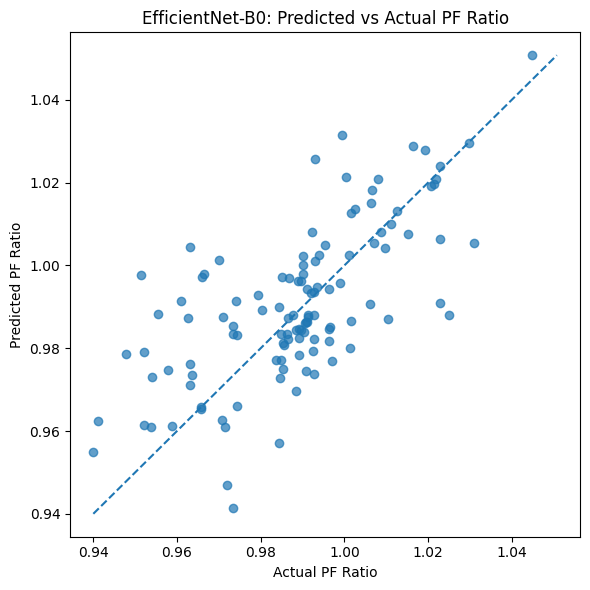


Model saved to: efficientnet_b0_el_pf_ratio_from_AnonDB.pth


In [ ]:
import os
import math
import copy
import random
from xml.parsers.expat import model
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"          # original CSV file
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
RANDOM_SEED = 42
NUM_WORKERS = 0   # use 0 first, especially on Windows/Jupyter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths like './EL/3903_35_1_01272020_20.tiff'
    into absolute paths based on the CSV/script directory.

    If add_wrp=True, convert:
    3903_35_1_01272020_20.tiff
    -> 3903_35_1_01272020_20_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    # Normalize slashes
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    # Add _wrp before file extension if needed
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    # If already absolute, keep it
    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    # Remove leading ./ if present
    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load original CSV, compute PF ratio, resolve paths, and
    keep only valid rows with existing low/high EL files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    # Convert power columns to numeric safely
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    # Remove invalid denominator
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    # Remove invalid numerator
    df = df[df["Pmp_(W)"].notna()]

    # Compute PF ratio
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Resolve actual paths
    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    # Remove missing path strings
    df = df[df["low_path"].notna()]
    df = df[df["high_path"].notna()]

    # Keep only rows whose image files actually exist
    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    # Keep only needed columns
    keep_cols = ["low_path", "high_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================

class SingleELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def apply_augmentation(self, img):
        # Horizontal flip
        if random.random() < 0.5:
            img = cv2.flip(img, 1)

        # Vertical flip
        if random.random() < 0.5:
            img = cv2.flip(img, 0)

        return img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ✅ Only one image now
        img = self.read_grayscale_tiff(row["high_path"])

        img = self.resize_image(img)

        if self.augment:
            img = self.apply_augmentation(img)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        img = np.expand_dims(img, axis=0)

        x = torch.tensor(img, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y

# Define BoundedOutput FIRST (before the build function)
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val

# =========================================================
# MODEL ini yang bikin copilot
# =========================================================
def build_efficientnet_b0_1ch(pretrained=True):
    model = models.efficientnet_b0(pretrained=pretrained)

    # Modify first conv layer to accept 1 channel
    original_conv = model.features[0][0]
    new_conv = nn.Conv2d(
        in_channels=1,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=original_conv.bias is not None
    )

    if pretrained:
        with torch.no_grad():
            new_conv.weight[:, 0, :, :] = original_conv.weight.mean(dim=1)

    model.features[0][0] = new_conv

    # Modify classifier for regression
    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # Prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    # Scaling the target variable (pf_ratio) can help training stability
    from sklearn.preprocessing import MinMaxScaler

    #scaler = MinMaxScaler()
    #df["pf_ratio"] = scaler.fit_transform(df[["pf_ratio"]])

# Save scaler to inverse transform predictions later
# predicted_pr = scaler.inverse_transform(raw_predictions)

    if len(df) < 10:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # Train / validation split
    # -------------------------
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")

    # -------------------------
    # Dataset / loader
    # -------------------------
    train_dataset = SingleELDataset(train_df, image_size=IMAGE_SIZE, augment=True)
    val_dataset = SingleELDataset(val_df, image_size=IMAGE_SIZE, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_efficientnet_b0_1ch(pretrained=True).to(DEVICE)

    # model freezing (optional, can be tuned)
    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

# Only train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    criterion = nn.SmoothL1Loss() #dari nn.MSELoss coba ke nn.SmoothL1Loss untuk lihat perbedaan MAE vs MSE
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    # -------------------------
    # Train loop
    # -------------------------
    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(model, val_loader, criterion, DEVICE)

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    # -------------------------
    # Final evaluation
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, preds, trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    print("\nBest Validation Performance")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    # -------------------------
    # Scatter plot: actual vs predicted
    # -------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Actual PF Ratio")
    plt.ylabel("Predicted PF Ratio")
    plt.title("EfficientNet-B0: Predicted vs Actual PF Ratio")
    plt.tight_layout()
    plt.savefig("scatter_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------
    # Save model
    # -------------------------

    # -------------------------
    # Save model
    # -------------------------
    save_path = "efficientnet_b0_el_pf_ratio_from_AnonDB.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()